In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import pandas as pd
import numpy as np

In [2]:
from models.walkforward.walkforward_runner import load_gold_dataset, prepare_features_and_target

df = load_gold_dataset()
X, y = prepare_features_and_target(df)

print(df.shape)
print(X.shape)
print(y.shape)
print(df.index.min(), df.index.max())

(62764, 13)
(62764, 6)
(62764,)
2019-01-01 12:00:00 2026-03-03 03:00:00


In [4]:
from models.walkforward.walkforward_runner import generate_expanding_windows

windows = generate_expanding_windows(df, initial_train_years=3, test_months=6)

print("Total windows:", len(windows))

for i, w in enumerate(windows):
    print(i+1, w)

Total windows: 8
1 {'train_start': Timestamp('2019-01-01 12:00:00'), 'train_end': Timestamp('2022-01-01 12:00:00'), 'test_start': Timestamp('2022-01-01 12:00:00'), 'test_end': Timestamp('2022-07-01 12:00:00')}
2 {'train_start': Timestamp('2019-01-01 12:00:00'), 'train_end': Timestamp('2022-07-01 12:00:00'), 'test_start': Timestamp('2022-07-01 12:00:00'), 'test_end': Timestamp('2023-01-01 12:00:00')}
3 {'train_start': Timestamp('2019-01-01 12:00:00'), 'train_end': Timestamp('2023-01-01 12:00:00'), 'test_start': Timestamp('2023-01-01 12:00:00'), 'test_end': Timestamp('2023-07-01 12:00:00')}
4 {'train_start': Timestamp('2019-01-01 12:00:00'), 'train_end': Timestamp('2023-07-01 12:00:00'), 'test_start': Timestamp('2023-07-01 12:00:00'), 'test_end': Timestamp('2024-01-01 12:00:00')}
5 {'train_start': Timestamp('2019-01-01 12:00:00'), 'train_end': Timestamp('2024-01-01 12:00:00'), 'test_start': Timestamp('2024-01-01 12:00:00'), 'test_end': Timestamp('2024-07-01 12:00:00')}
6 {'train_start': 

In [5]:
from models.walkforward.walkforward_runner import split_window

X, y = prepare_features_and_target(df)

w0 = windows[0]

X_train, y_train, X_test, y_test = split_window(X, y, w0)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Train range:", X_train.index.min(), "->", X_train.index.max())
print("Test range:", X_test.index.min(), "->", X_test.index.max())

Train shape: (26245, 6)
Test shape: (4344, 6)
Train range: 2019-01-01 12:00:00 -> 2022-01-01 11:00:00
Test range: 2022-01-01 12:00:00 -> 2022-07-01 11:00:00


In [6]:
from models.walkforward.walkforward_runner import scale_window

X_train_s, X_test_s, scaler = scale_window(X_train, X_test)

print(X_train_s.shape, X_test_s.shape)

(26245, 6) (4344, 6)


In [7]:
from models.walkforward.walkforward_runner import get_model

m1 = get_model("logistic")
m2 = get_model("rf")
m3 = get_model("xgb")

print(type(m1), type(m2), type(m3))

<class 'sklearn.linear_model._logistic.LogisticRegression'> <class 'sklearn.ensemble._forest.RandomForestClassifier'> <class 'xgboost.sklearn.XGBClassifier'>


In [ ]:
from models.walkforward.walkforward_runner import (
    load_gold_dataset,
    prepare_features_and_target,
    generate_expanding_windows,
)

df = load_gold_dataset()
X, y = prepare_features_and_target(df)
windows = generate_expanding_windows(df, initial_train_years=3, test_months=6)

print("Total windows:", len(windows))

Total windows: 8


In [14]:
from models.walkforward.walkforward_runner import run_walkforward_for_model

for model_name in ["logistic", "rf", "xgb"]:

    df_model, equity_curve, returns = run_walkforward_for_model(
        X,
        y,
        df,       
        windows,
        model_name=model_name,
        threshold=0.5,
        save_results=True,
    )

    print(model_name.upper())
    print(df_model[["window", "auc", "sharpe"]])
    print()

LOGISTIC
   window       auc    sharpe
0       1  0.533042 -3.648503
1       2  0.544265 -0.408990
2       3  0.560355  1.975047
3       4  0.555880  3.761481
4       5  0.538016  2.359631
5       6  0.536696  3.588808
6       7  0.539597  2.320276
7       8  0.523209 -1.501233

RF
   window       auc    sharpe
0       1  0.518235 -1.502144
1       2  0.523436 -0.906888
2       3  0.537011  3.351986
3       4  0.544728  3.327735
4       5  0.538843  3.407049
5       6  0.525672  3.127354
6       7  0.498185  0.304812
7       8  0.536409  0.796648

XGB
   window       auc    sharpe
0       1  0.524999 -2.444417
1       2  0.546429 -0.534375
2       3  0.539798  2.716035
3       4  0.553136  2.170118
4       5  0.543486  2.454564
5       6  0.541421  3.893979
6       7  0.526044  1.490556
7       8  0.537366 -0.736764



In [15]:
for model_name in ["logistic", "rf", "xgb"]:

    df_model, equity_curve, returns = run_walkforward_for_model(
        X,
        y,
        df, 
        windows,
        model_name=model_name,
        threshold=0.5,
        save_results=True,
    )

    print(model_name.upper())
    print("Mean Sharpe:", df_model["sharpe"].mean())
    print("Std Sharpe:", df_model["sharpe"].std())
    print("Windows Sharpe < 0:", (df_model["sharpe"] < 0).sum())

LOGISTIC
Mean Sharpe: 1.0558144684986244
Std Sharpe: 2.637510329938559
Windows Sharpe < 0: 3
RF
Mean Sharpe: 1.4883191457432128
Std Sharpe: 2.0627183206077633
Windows Sharpe < 0: 2
XGB
Mean Sharpe: 1.12621199080691
Std Sharpe: 2.143185255887094
Windows Sharpe < 0: 3


In [16]:
for model_name in ["logistic", "rf", "xgb"]:

    df_model, equity_curve, returns = run_walkforward_for_model(
        X,
        y,
        df,        
        windows,
        model_name=model_name,
        threshold=0.5,
        save_results=True,
    )

    print(model_name.upper())   
    print(len(equity_curve))
    print(equity_curve[-5:])

LOGISTIC
35063
[2.71275872 2.72060113 2.72283047 2.72465512 2.72287252]
RF
35063
[10.06506114 10.09415858 10.09415858 10.09415858 10.09415858]
XGB
35063
[4.37000077 4.37000077 4.37000077 4.37000077 4.37000077]


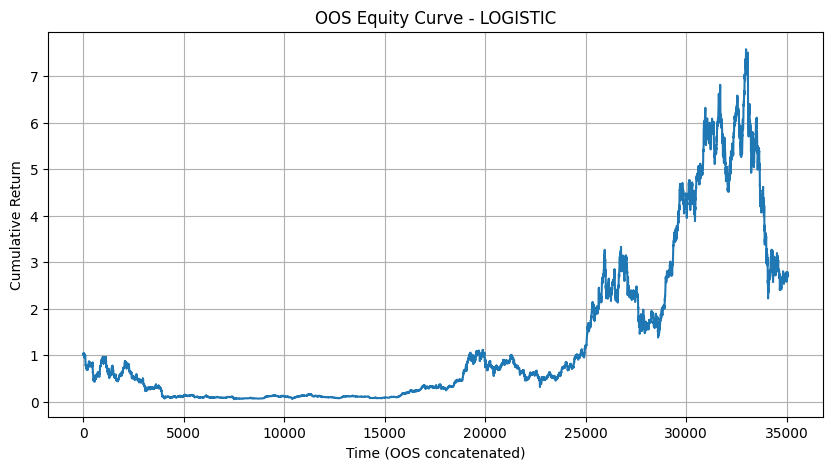

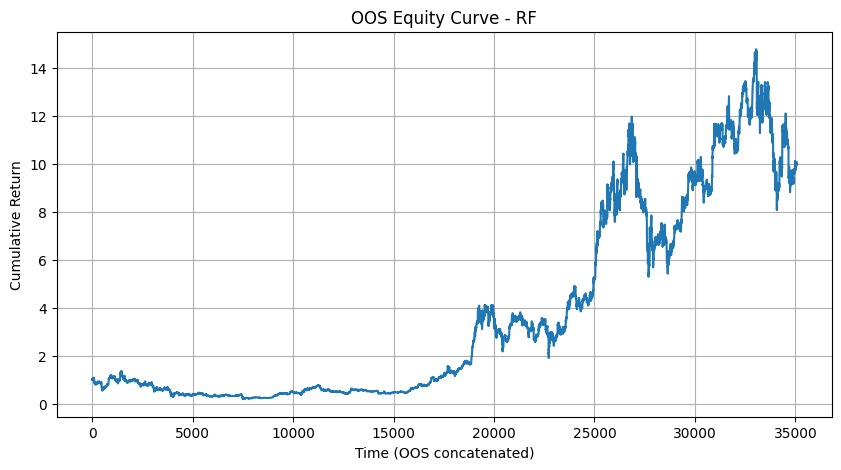

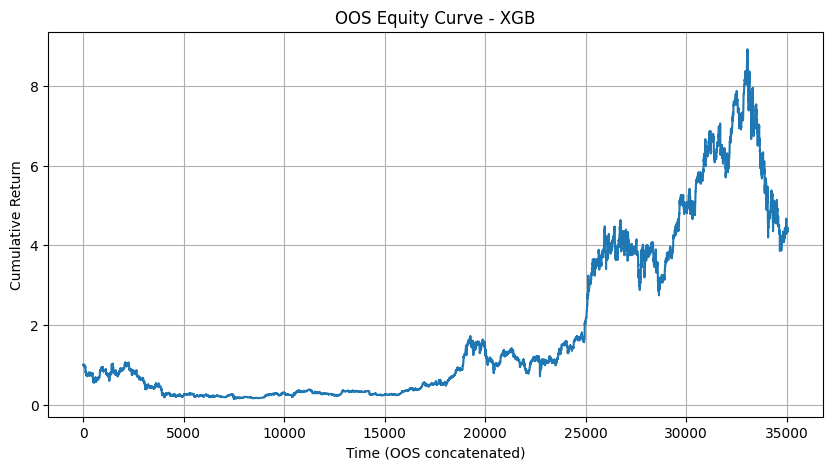

In [17]:
import matplotlib.pyplot as plt

for model_name in ["logistic", "rf", "xgb"]:

    df_model, equity_curve, returns = run_walkforward_for_model(
        X,
        y,
        df,
        windows,
        model_name=model_name,
        threshold=0.5,
        save_results=True,
    )

    plt.figure(figsize=(10,5))
    plt.plot(equity_curve)
    plt.title(f"OOS Equity Curve - {model_name.upper()}")
    plt.xlabel("Time (OOS concatenated)")
    plt.ylabel("Cumulative Return")
    plt.grid(True)
    plt.show()

In [18]:
for model_name in ["logistic", "rf", "xgb"]:

    df_model, equity_curve, returns = run_walkforward_for_model(
        X,
        y,
        df,       
        windows,
        model_name=model_name,
        threshold=0.5,
        save_results=True,
    )

    mean_ret = returns.mean()
    std_ret = returns.std()
    sharpe_global = (mean_ret / std_ret) * np.sqrt(365*24)

    print(model_name.upper())   
    print(sharpe_global)

LOGISTIC
0.7112731164529856
RF
1.1979329041353888
XGB
0.8812021892576565


In [19]:
from scipy.stats import linregress

for model_name in ["logistic", "rf", "xgb"]:

    df_model, equity_curve, returns = run_walkforward_for_model(
        X,
        y,
        df,      
        windows,
        model_name=model_name,
        threshold=0.5,
        save_results=True,
    )

    slope_auc = linregress(df_model["window"], df_model["auc"]).slope
    slope_sharpe = linregress(df_model["window"], df_model["sharpe"]).slope

    print(model_name.upper())       
    print("AUC slope:", slope_auc)
    print("Sharpe slope:", slope_sharpe)

LOGISTIC
AUC slope: -0.0021549034460200175
Sharpe slope: 0.3823411278999145
RF
AUC slope: -0.0004636472335463855
Sharpe slope: 0.2566126545774058
XGB
AUC slope: -0.00023976716999716765
Sharpe slope: 0.3082917299429117
